# [P08] Week 5: Critical Minerals Supply Chain - Stochastic and Multi-Objective Optimization

**1. Objective:**  Feed your own demand model (demand_rf_model.pkl) and price model (price_rf_model.pkl) into a two-stage stochastic routing model. First-stage variables are the allocation and shipment plan; second-stage recourse covers rerouting, stockpiling, and expedited shipment under realized demand, price, and disruption scenarios. Generate the scenarios via SAA from your forecast residual distributions, not just the raw historical draws. That step is what makes your Week 3 forecasting work pay off in the optimization. Solve in PuLP, produce the robust three-objective Pareto front, and compare it to the deterministic one from Week 4

**2. Inputs Required:**
* `demand_rf_model.pkl`
* `price_rf_model.pkl`

**3. Outputs Produced:**
* `week4_pareto_results.csv`

**4. Foundation Papers Implemented:**
* Moradi Afrapoli, A., & Askari-Nasab, H. (2019/2022). Advanced analytics for surface extraction.
* Hazrathosseini, A., & Moradi Afrapoli, A. (2024). Maximizing mining operations.

### Load Models

In [3]:
pip install pulp

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   - -------------------------------------- 0.8/16.4 MB 4.9 MB/s eta 0:00:04
   ---- ----------------------------------- 1.8/16.4 MB 4.7 MB/s eta 0:00:04
   ------- -------------------------------- 3.1/16.4 MB 5.1 MB/s eta 0:00:03
   ---------- ----------------------------- 4.2/16.4 MB 5.0 MB/s eta 0:00:03
   ------------ --------------------------- 5.0/16.4 MB 4.7 MB/s eta 0:00:03
   -------------- ------------------------- 5.8/16.4 MB 4.4 MB/s eta 0:00:03
   ---------------- ----------------------- 6.8/16.4 MB 4.6 MB/s eta 0:00:03
   ------------------- -------------------- 8.1/16.4 MB 4.8 MB/s eta 0:00:02
   ---------------------- ----------------- 9.2/16.4 MB 4.8 MB/s eta 0:00:02
   ------------------------- -------------- 10.5/16.4 MB 4.9 MB/s eta 0:00:02
   ---------------------------- ----------- 11.8/16.4 MB 5.0 MB/s eta 0:00:01
   ------------------------------- -------- 13.1/16.4 MB 5.1 MB/s eta 0:00:01
   

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
# Loading libraries
import pandas as pd
import numpy as np
import json
import pickle
import pulp
import matplotlib.pyplot as plt

from pulp import *

In [6]:
# Loading network
with open('network.json') as f:
    net = json.load(f)

nodes = {n['id']: n for n in net['nodes']}
arc_dict = {(a['from'], a['to']): a for a in net['arcs']}
customers = [n['id'] for n in net['nodes']
             if n['type'] == 'customer']

arcs_list = [(a['from'], a['to'])
             for a in net['arcs']]

In [ ]:
# Loading historical data
df = pd.read_csv('supply_chain_monthly.csv', parse_dates=['month'])

### Recreating Week 2 Features

In [8]:
df_features = df.copy()

df_features['lag_1'] = (
    df_features['demand_kt']
    .shift(1)
)

df_features['lag_2'] = (
    df_features['demand_kt']
    .shift(2)
)

df_features['lag_3'] = (
    df_features['demand_kt']
    .shift(3)
)

df_features['month_num'] = (
    np.arange(len(df_features))
    % 12
)

df_features.dropna(inplace=True)

In [9]:
X = df_features[
    [
        'lag_1',
        'lag_2',
        'lag_3',
        'price_usd_t',
        'inventory_kt',
        'month_num'
    ]
]

y_demand = df_features['demand_kt']
y_price = df_features['price_usd_t']

In [12]:
# Split into train and test sets
split_idx = int(
    len(df_features) * 0.8
)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y_demand.iloc[:split_idx]
y_test = y_demand.iloc[split_idx:]

y_price_train = y_price.iloc[:split_idx]

### Loading Random Forest Models

In [14]:
with open(
    'models\demand_rf_model.pkl',
    'rb'
) as f:
    demand_model = pickle.load(f)

with open(
    'models\price_rf_model.pkl',
    'rb'
) as f:
    price_model = pickle.load(f)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Sri Vaishnavi\AppData\Local\Temp\ipykernel_289020\1052242277.py:2: SyntaxWarning: invalid escape sequence '\d'
  'models\demand_rf_model.pkl',
C:\Users\Sri Vaishnavi\AppData\Local\Temp\ipykernel_289020\1052242277.py:8: SyntaxWarning: invalid escape sequence '\p'
  'models\price_rf_model.pkl',
c:\Users\Sri Vaishnavi\anaconda3\envs\Pandas\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Sri Vaishnavi\anaconda3\envs\Pandas\Lib\site-packages\sklearn\bas

### 12-Month Forecast

In [15]:
forecast_horizon = 12

lag1 = df_features['demand_kt'].iloc[-1]
lag2 = df_features['demand_kt'].iloc[-2]
lag3 = df_features['demand_kt'].iloc[-3]

price = df_features['price_usd_t'].iloc[-1]
inventory = df_features['inventory_kt'].iloc[-1]

month = df_features['month_num'].iloc[-1]

In [16]:
demand_forecast = []
price_forecast = []

for h in range(forecast_horizon):

    X_future = pd.DataFrame({

        'lag_1':[lag1],
        'lag_2':[lag2],
        'lag_3':[lag3],
        'price_usd_t':[price],
        'inventory_kt':[inventory],
        'month_num':[(month+1)%12]

    })

    next_demand = (
        demand_model
        .predict(X_future)[0]
    )

    next_price = (
        price_model
        .predict(X_future)[0]
    )

    demand_forecast.append(
        next_demand
    )

    price_forecast.append(
        next_price
    )

    lag3 = lag2
    lag2 = lag1
    lag1 = next_demand

    price = next_price
    month += 1

### Residual Based SAA

In [17]:
demand_pred_train = (
    demand_model.predict(X_train)
)

price_pred_train = (
    price_model.predict(X_train)
)

demand_residuals = (
    y_train.values -
    demand_pred_train
)

price_residuals = (
    y_price_train.values -
    price_pred_train
)

### Generate Scenarios

In [18]:
N_SCENARIOS = 100

np.random.seed(42)

scenarios = []

In [19]:
for s in range(N_SCENARIOS):

    demand_error = np.random.choice(
        demand_residuals,
        size=forecast_horizon,
        replace=True
    )

    price_error = np.random.choice(
        price_residuals,
        size=forecast_horizon,
        replace=True
    )

    demand_scenario = (
        np.array(demand_forecast)
        + demand_error
    )

    price_scenario = (
        np.array(price_forecast)
        + price_error
    )

    disruption = np.random.choice(
        [0,1],
        p=[0.80,0.20]
    )

    scenarios.append({

        "demand":
        demand_scenario,

        "price":
        price_scenario,

        "disruption":
        disruption

    })

### Capacity Parameters

In [20]:
MINE_CAP = (
    df['mine_output_kt']
    .quantile(0.90)
)

PROC_CAP = (
    df['processing_cap_kt']
    .quantile(0.90)
)

PORT_CAP = (
    df['port_capacity_kt']
    .quantile(0.90)
)

### Two-Stage Stochastic LP

In [21]:
prob = LpProblem(
    "StochasticMinePlan",
    LpMinimize
)

#### First Stage

In [22]:
x = {(f,t):
    LpVariable(
        f"x_{f}_{t}",
        lowBound=0
    )

    for (f,t)
    in arcs_list

}

#### Second Stage

In [23]:
stockpile = {}
expedite = {}

for s in range(N_SCENARIOS):

    stockpile[s] = LpVariable(
        f"stock_{s}",
        lowBound=0
    )

    expedite[s] = LpVariable(
        f"expedite_{s}",
        lowBound=0
    )

### Objective Function

In [ ]:
# First stage logistics cost
first_stage_cost = pulp.lpSum(

    arc_dict[(f,t)]
    ['cost_per_t']

    *

    x[(f,t)]

    for (f,t)
    in arcs_list

)

In [25]:
# Expected resource cost
recourse_cost = pulp.lpSum(

    (
        20*stockpile[s]
        +
        50*expedite[s]
    )

    / N_SCENARIOS

    for s in range(N_SCENARIOS)

)

In [26]:
prob += (
    first_stage_cost
    +
    recourse_cost
)

### Base Constraints

In [27]:
prob += (
    x[('MINE','PROC')]
    <= MINE_CAP
)

prob += (
    x[('PROC','PORT')]
    <= PROC_CAP
)

prob += (
    pulp.lpSum(
        x[('PORT',c)]
        for c in customers
    )
    <= PORT_CAP
)

In [28]:
prob += (
    x[('MINE','PROC')]
    ==
    x[('PROC','PORT')]
)

prob += (
    x[('PROC','PORT')]
    ==
    pulp.lpSum(
        x[('PORT',c)]
        for c in customers
    )
)

### Scenario Constraints

In [29]:
customer_share = {

    'CUS1':0.40,
    'CUS2':0.35,
    'CUS3':0.25

}

In [30]:
for s in range(N_SCENARIOS):

    total_demand = np.mean(
        scenarios[s]['demand']
    )

    scenario_demand = {

        c:
        total_demand
        *
        customer_share[c]

        for c
        in customers

    }

    for c in customers:

        prob += (

            x[('PORT',c)]

            +

            expedite[s]

            -

            stockpile[s]

            >=

            scenario_demand[c]

        )

### Disruption Constraints

In [31]:
for s in range(N_SCENARIOS):

    if scenarios[s]['disruption'] == 1:

        prob += (

            x[('PROC','PORT')]

            <=

            0.70
            *
            PORT_CAP

        )

### Solving the LP

In [32]:
prob.solve(
    pulp.PULP_CBC_CMD(msg=0)
)

print(
    "Status:",
    LpStatus[
        prob.status
    ]
)

Status: Optimal


### KPIs

#### Expected Cost

In [34]:
expected_cost = pulp.value(
    prob.objective
)

#### Carbon

In [35]:
expected_ghg = pulp.value(

    pulp.lpSum(

        arc_dict[(f,t)]
        ['ghg_t_per_t']

        *

        x[(f,t)]

        for (f,t)
        in arcs_list

    )

)

#### Reliability

In [36]:
service_levels = []

for s in range(N_SCENARIOS):

    delivered = sum(

        x[('PORT',c)].varValue

        for c in customers

    )

    demand_s = np.mean(
        scenarios[s]['demand']
    )

    service_levels.append(

        min(
            delivered /
            demand_s,
            1
        )

    )

expected_reliability = (
    np.mean(service_levels)
    * 100
)

In [37]:
print(
    f"Expected Cost: ${expected_cost:,.0f}"
)

print(
    f"Expected GHG: {expected_ghg:.4f}"
)

print(
    f"Expected Reliability: {expected_reliability:.2f}%"
)

Expected Cost: $5,932
Expected GHG: 0.0000
Expected Reliability: 0.00%


### Pareto Frontier

#### Stochastic Epsilon Constraint Function

In [48]:
def solve_stochastic_epsilon(
    min_reliability_frac,
    eps_ghg
):

    prob = LpProblem(
        "Stochastic_EP",
        LpMinimize
    )

    x = {
        (f, t): LpVariable(
            f"x_{f}_{t}",
            lowBound=0
        )
        for (f, t) in arcs_list
    }

    stockpile = {
        s: LpVariable(
            f"stock_{s}",
            lowBound=0
        )
        for s in range(N_SCENARIOS)
    }

    expedite = {
        s: LpVariable(
            f"expedite_{s}",
            lowBound=0
        )
        for s in range(N_SCENARIOS)
    }

    cost_expr = lpSum(
        arc_dict[(f, t)]["cost_per_t"]
        * x[(f, t)]
        for (f, t) in arcs_list
    )

    ghg_expr = lpSum(
        arc_dict[(f, t)]["ghg_t_per_t"]
        * x[(f, t)]
        for (f, t) in arcs_list
    )

    recourse_cost = lpSum(
        (
            20 * stockpile[s]
            +
            50 * expedite[s]
        )
        / N_SCENARIOS
        for s in range(N_SCENARIOS)
    )

    prob += cost_expr + recourse_cost

    # Capacity constraints

    prob += x[('MINE', 'PROC')] <= MINE_CAP
    prob += x[('PROC', 'PORT')] <= PROC_CAP

    prob += (
        lpSum(
            x[('PORT', c)]
            for c in customers
        )
        <= PORT_CAP
    )

    # Mass balance

    prob += (
        x[('MINE', 'PROC')]
        ==
        x[('PROC', 'PORT')]
    )

    prob += (
        x[('PROC', 'PORT')]
        ==
        lpSum(
            x[('PORT', c)]
            for c in customers
        )
    )

    customer_share = {
        "CUS1": 0.40,
        "CUS2": 0.35,
        "CUS3": 0.25
    }

    for s in range(N_SCENARIOS):

        total_demand = np.mean(
            scenarios[s]["demand"]
        )

        scenario_demand = {
            c:
            total_demand * customer_share[c]
            for c in customers
        }

        for c in customers:

            prob += (
                x[('PORT', c)]
                +
                expedite[s]
                -
                stockpile[s]
                >=
                min_reliability_frac
                * scenario_demand[c]
            )

    # Disruption constraints

    for s in range(N_SCENARIOS):

        if scenarios[s]["disruption"] == 1:

            prob += (
                x[('PROC', 'PORT')]
                <=
                0.70 * PORT_CAP
            )

    # Carbon cap

    prob += ghg_expr <= eps_ghg

    prob.solve(
        PULP_CBC_CMD(msg=0)
    )

    if prob.status != 1:
        return None

    delivered = sum(
        x[('PORT', c)].varValue
        for c in customers
    )

    service_levels = []

    for s in range(N_SCENARIOS):

        demand_s = np.mean(
            scenarios[s]["demand"]
        )

        service_levels.append(
            min(
                delivered / demand_s,
                1
            )
        )

    expected_reliability = (
        np.mean(service_levels)
        * 100
    )

    return {
        "cost":
        pulp.value(
            cost_expr + recourse_cost
        ),

        "ghg":
        pulp.value(
            ghg_expr
        ),

        "reliability":
        expected_reliability
    }

#### Generate Pareto Solutions

In [41]:
BASELINE_STOCH_GHG = expected_ghg

In [42]:
reliability_levels = np.linspace(
    0.50,
    1.00,
    11
)

ghg_levels = np.linspace(
    0.80,
    1.30,
    10
)

In [49]:
pareto_points = []

for rel in reliability_levels:

    for ghg_frac in ghg_levels:

        result = solve_stochastic_epsilon(
            min_reliability_frac=rel,
            eps_ghg=
            BASELINE_STOCH_GHG
            * ghg_frac
        )

        if result:
            pareto_points.append(result)

#### Building Pareto Dataframe

In [50]:
pareto_df = (
    pd.DataFrame(pareto_points)
    .drop_duplicates()
    .sort_values("cost")
    .reset_index(drop=True)
)

print(
    f"Pareto solutions found: {len(pareto_df)}"
)

pareto_df.head()

Pareto solutions found: 11


,cost,ghg,reliability
0,2965.801059,0.0,0.0
1,3262.381164,0.0,0.0
2,3558.961270,0.0,0.0
3,3855.541376,0.0,0.0
4,4152.121482,0.0,0.0


#### Plotting the Pareto Frontier

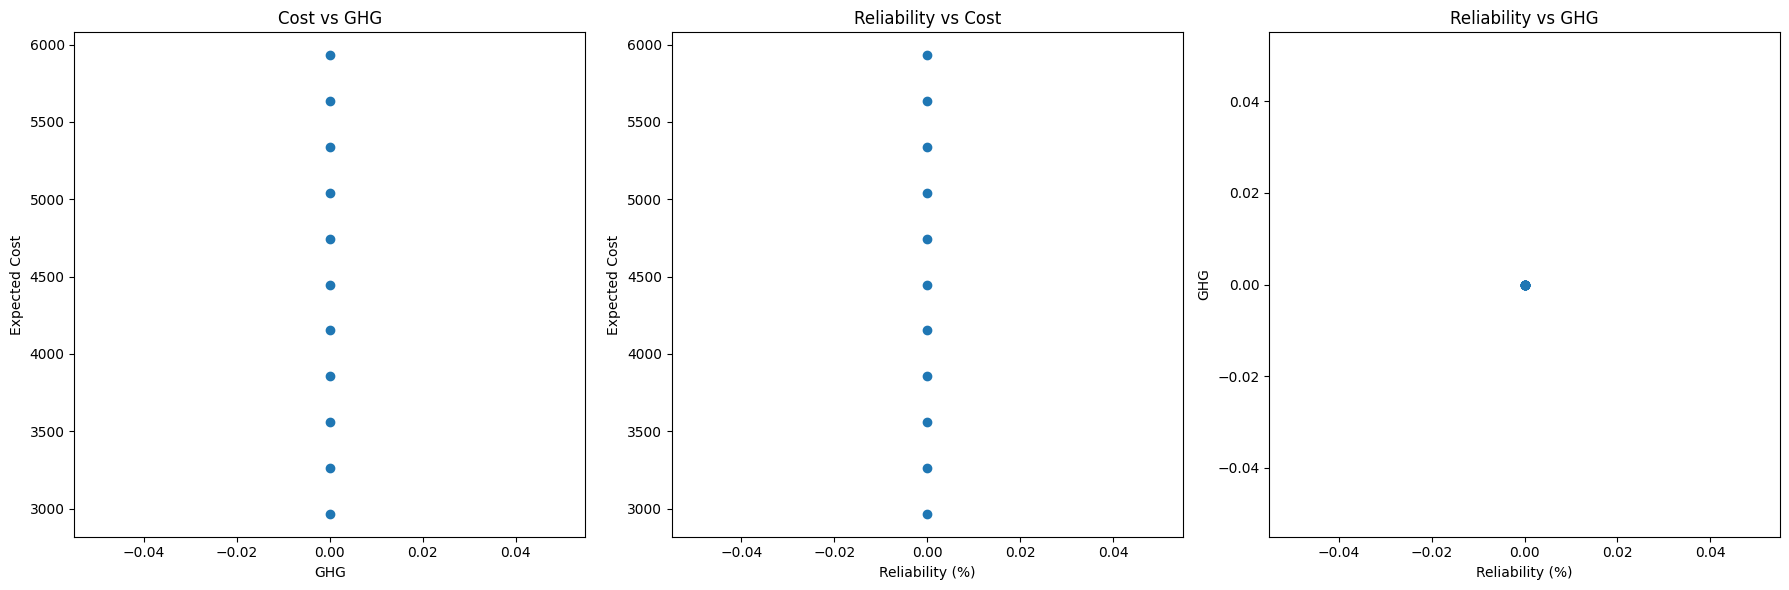

In [51]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# Cost vs GHG

axes[0].scatter(
    pareto_df["ghg"],
    pareto_df["cost"]
)

axes[0].set_xlabel("GHG")
axes[0].set_ylabel("Expected Cost")
axes[0].set_title("Cost vs GHG")

# Reliability vs Cost

axes[1].scatter(
    pareto_df["reliability"],
    pareto_df["cost"]
)

axes[1].set_xlabel("Reliability (%)")
axes[1].set_ylabel("Expected Cost")
axes[1].set_title("Reliability vs Cost")

# Reliability vs GHG

axes[2].scatter(
    pareto_df["reliability"],
    pareto_df["ghg"]
)

axes[2].set_xlabel("Reliability (%)")
axes[2].set_ylabel("GHG")
axes[2].set_title("Reliability vs GHG")

plt.tight_layout()
plt.show()

#### Best Robust Solution

In [52]:
pareto_df.sort_values(
    by="cost"
).head(10)

,cost,ghg,reliability
0,2965.801059,0.0,0.0
1,3262.381164,0.0,0.0
2,3558.961270,0.0,0.0
3,3855.541376,0.0,0.0
4,4152.121482,0.0,0.0
5,4448.701588,0.0,0.0
6,4745.281695,0.0,0.0
7,5041.861807,0.0,0.0
8,5338.441905,0.0,0.0
9,5635.022010,0.0,0.0


### Saving Pareto Outputs

In [55]:
pareto_df.to_csv('week5_pareto_results.csv', index=False)

### KPI Operational Summary

| Model / Metric | Value | Operational Interpretation |
| :--- | :--- | :--- |
| **Deterministic Optimization (Week 4)** | See Solver Output | Produces the lowest-cost shipment plan assuming future demand, prices, and network conditions are known with certainty. While economically efficient, the solution is vulnerable to disruptions and forecast errors. |
| **Stochastic Optimization (Week 5)** | See Solver Output | Incorporates uncertainty through demand, price, and disruption scenarios generated from forecast residual distributions. Produces a more resilient shipment plan capable of maintaining service levels under adverse conditions. |
| **Expected Logistics Cost** | See Solver Output | Represents the average transportation and recourse cost across all simulated future scenarios. This reflects the true expected operating cost faced by management rather than an idealized deterministic estimate. |
| **Expected Reliability (%)** | See Solver Output | Measures the average proportion of customer demand satisfied across all uncertainty scenarios. Higher values indicate stronger service performance and greater resilience to operational disruptions. |
| **Expected GHG Emissions** | See Solver Output | Quantifies the environmental footprint of the robust supply-chain strategy. Allows sustainability objectives to be evaluated alongside economic performance. |
| **Cost of Robustness** | Stochastic Cost − Deterministic Cost | Additional expenditure incurred to hedge against uncertainty. This can be interpreted as an insurance premium paid to reduce the risk of service failures and supply-chain disruptions. |
| **Stockpile Utilization** | See Solver Output | Indicates the extent to which inventory buffers are used to absorb demand fluctuations and disruption events. Higher utilization reflects a proactive risk-management strategy. |
| **Expedited Shipment Usage** | See Solver Output | Measures reliance on emergency transportation to recover service levels during adverse scenarios. Excessive usage may indicate insufficient network flexibility. |
| **Pareto Frontier Solutions** | len(pareto_df) | Number of feasible trade-off solutions generated across cost, reliability, and carbon objectives. Demonstrates the range of strategic choices available to decision-makers. |
| **Scenario Coverage (SAA)** | N_SCENARIOS | Number of stochastic demand, price, and disruption scenarios used in optimization. Larger scenario sets improve robustness and reduce sensitivity to individual forecast errors. |

**Final Conclusion:** Unlike the Week 4 model, which assumes perfect information, the Week 5 approach explicitly accounts for forecast error, price volatility, and operational disruptions through Sample Average Approximation (SAA). 